In [6]:
import pandas as pd
import os 

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import numpy as np

 # Load the dataset
test = "test_1"
df = pd.read_csv('./data/'+test+'/robot_log.csv', delimiter=';')
#df


image_dir = 'data/'+test+'/IMG/'
#df['Path'] = df['Path'].apply(lambda p: os.path.basename(p)).replace('\\', '/')
df['Path'] = df['Path'].str.replace(r'^C:\\Users\\Chris SB\\Downloads\\IMG\\', '', regex=True)
## Update the Path column to have full paths
df['Path'] = df['Path'].apply(lambda x: os.path.join(image_dir, x))
df = df.sample(frac=1).reset_index(drop=True)


 # Select relevant columns
df = df[['Path', 'SteerAngle', 'Throttle']]
len(df)

1982

data/test_1/IMG/robocam_2025_04_05_08_47_00_091.jpg
2.894792
1.0


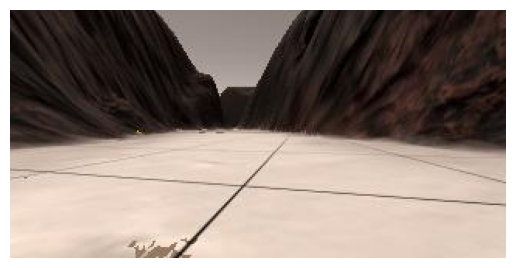

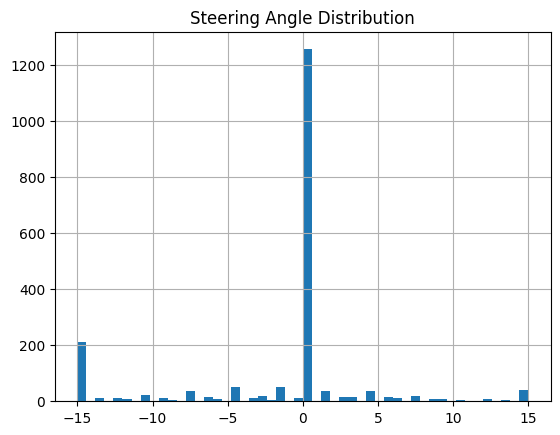

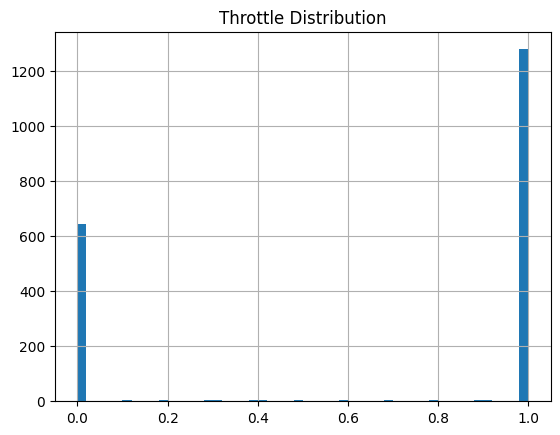

In [11]:
img_path = df['Path'][20]
print(img_path)
print(df['SteerAngle'][20])
print(df['Throttle'][20])
img = mpimg.imread(img_path)
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()

df['SteerAngle'].hist(bins=50)
plt.title('Steering Angle Distribution')
plt.show()

df['Throttle'].hist(bins=50)
plt.title('Throttle Distribution')
plt.show()

In [12]:
# Set the overrepresented steering angle and desired count
oversampled_angle = 0.0
desired_count = 300

# Separate the DataFrame into the oversampled group and the rest
df_oversampled = df[df['SteerAngle'] == oversampled_angle]
df_rest = df[df['SteerAngle'] != oversampled_angle]

# Check current number of oversampled instances (should be ~1200)
print("Oversampled count before:", len(df_oversampled))

# Downsample the oversampled group to the desired count
df_oversampled_downsampled = df_oversampled.sample(n=desired_count, random_state=42)

# Combine the downsampled group with the rest of the data
df_downsampled = pd.concat([df_oversampled_downsampled, df_rest]).reset_index(drop=True)

print("Total count after downsampling:", len(df_downsampled))

Oversampled count before: 1250
Total count after downsampling: 1032


In [13]:
df_downsampled

,Path,SteerAngle,Throttle
0,data/test_1/IMG/robocam_2025_04_05_08_46_35_01...,0.000000,1.000000
1,data/test_1/IMG/robocam_2025_04_05_08_46_27_27...,0.000000,1.000000
2,data/test_1/IMG/robocam_2025_04_05_08_47_41_91...,0.000000,1.000000
3,data/test_1/IMG/robocam_2025_04_05_08_47_39_04...,0.000000,0.801357
4,data/test_1/IMG/robocam_2025_04_05_08_46_38_81...,0.000000,1.000000
...,...,...,...
1027,data/test_1/IMG/robocam_2025_04_05_08_46_15_40...,-7.589978,0.000000
1028,data/test_1/IMG/robocam_2025_04_05_08_48_03_38...,-7.431751,1.000000
1029,data/test_1/IMG/robocam_2025_04_05_08_47_42_71...,2.981403,1.000000
1030,data/test_1/IMG/robocam_2025_04_05_08_46_16_80...,-10.510480,0.300245


data/test_1/IMG/robocam_2025_04_05_08_48_02_319.jpg
0.0
1.0


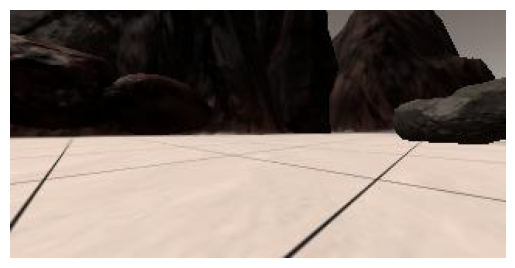

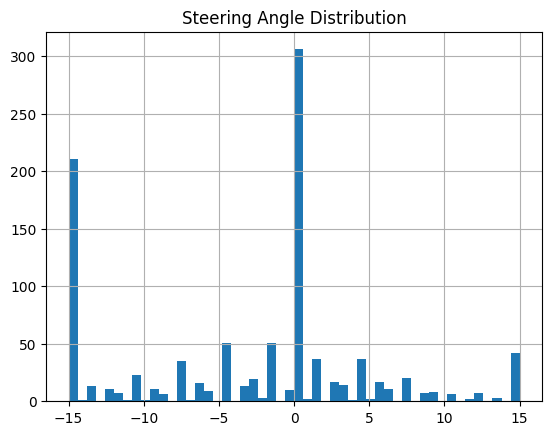

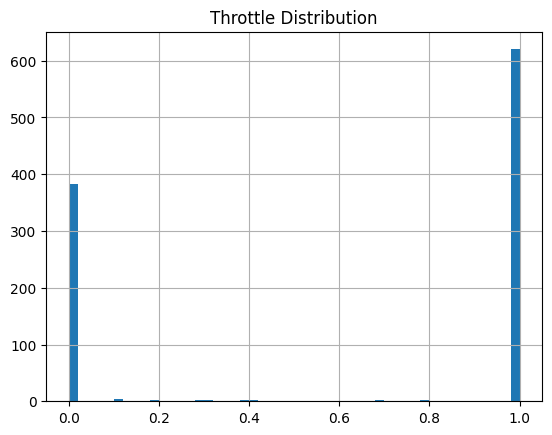

In [14]:


img_path = df_downsampled['Path'][20]
print(img_path)
print(df_downsampled['SteerAngle'][20])
print(df_downsampled['Throttle'][20])
img = mpimg.imread(img_path)
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()

df_downsampled['SteerAngle'].hist(bins=50)
plt.title('Steering Angle Distribution')
plt.show()

df_downsampled['Throttle'].hist(bins=50)
plt.title('Throttle Distribution')
plt.show()